# Exercise 1

We first load a dataset and examine its dimensions.

In [4]:
# If you are running this on Google Colab, uncomment and run the following lines; otherwise ignore this cell
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import math
import numpy as np

xy_data = np.load('/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy')
# If running on Google Colab change path to '/content/drive/MyDrive/IB-Data-Science/Exercises/Ex1_polyreg_data.npy'

np.shape(xy_data)

(70, 2)

The matrix `xy_data` contains $70$ rows, each a data point of the form $(x_i,y_i)$ for $i=1, \ldots, 70$.

### 1a) Plot the data in a scatterplot.

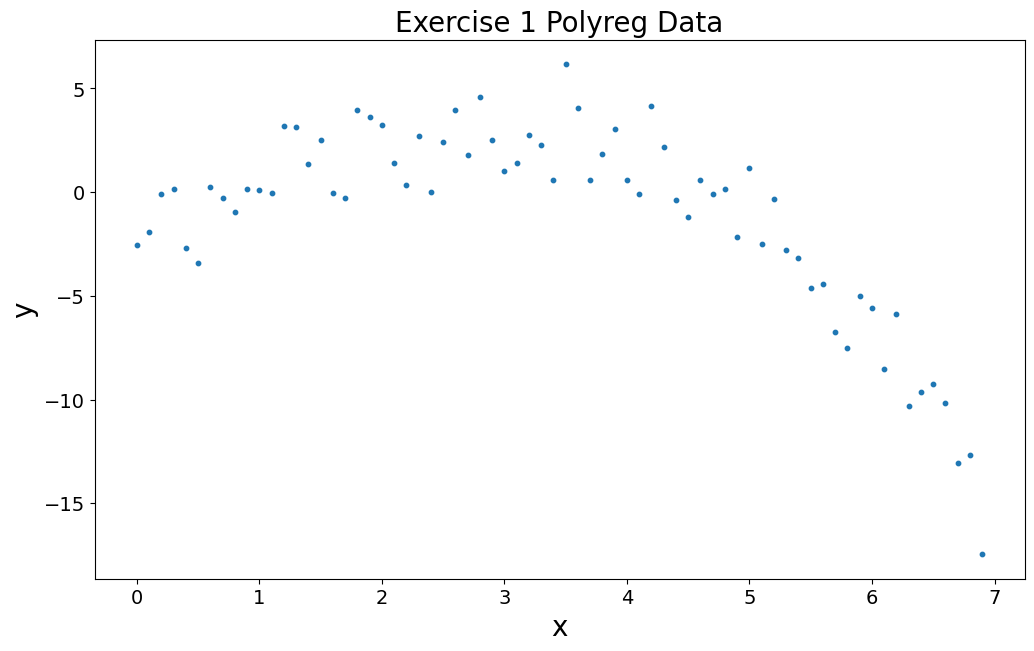

In [6]:
import matplotlib.pyplot as plt
# Your code for scatterplot here

x_data = xy_data[:,0]      # First column of array (indexed by 0) contains the x
y_data = xy_data[:,1]  # Second column of array (indexed by 1) contains the y


# Set parameters to make sure figures are large enough. You can try changing these values
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.scatter(x_data, y_data, s=10)   # s can be used to adjust the size of the dots
plt.xlabel('x')
plt.ylabel('y')
plt.title('Exercise 1 Polyreg Data')
plt.savefig('Exercise1_PolyregData.pdf', bbox_inches = 'tight')
plt.show()

### 1b) Write a function `polyreg` to fit a polynomial of a given order to a dataset.
The inputs to the function are a data matrix of dimension $N \times 2$,  and $k \geq 0$, the order of the polynomial.   The function should compute the coefficients of the polynomial $\beta_0 + \beta_1 x +  \ldots  +\beta_k x^{k}$ via least squares regression, and should return the coefficient vector, the fit, and the vector of residuals.

If specified the degree $k$ is greater than or equal to $N$, then the function must fit an order $(N-1)$ polynomial and set the remaining coefficients to zero.

**NOTE**: You are *not* allowed to use the built-in function `np.polyfit`.

In [27]:
def polyreg(data_matrix, k):
    # Your code here
    # The function should return the the coefficient vector beta, the fit, and the vector of residuals


    x_data = data_matrix[:,0]      # First column of array (indexed by 0) contains the x
    y_data = data_matrix[:,1]  # Second column of array (indexed by 1) contains the y
    all_ones = np.ones(np.shape(x_data))



    # Create a matrix X with the first column all ones, second column containing dates, the third col.
    # containing square of dates and the Kth col containing dates to the Kth power.
    Xk = np.ones(np.shape(x_data))
    #Reshape Xk to be 2D if k=0
    if k == 0:
        Xk = Xk[:, np.newaxis] # Reshape to a 2D array with one column

    for i in range(1, k+1):
        Xk = np.column_stack((Xk, np.power(x_data, i)))


    # Computing the coefficient vector beta* using least squares formula
    beta_k, sum_of_residual_squared, rank, s    =    np.linalg.lstsq(Xk, y_data, rcond=None)

    # Computing the fit of the quadratic model
    fit_k = Xk.dot(beta_k)

    # Computing the vector of residuals
    residuals_k = y_data - fit_k

    # Return the required outputs
    return beta_k, fit_k, residuals_k

Use the tests below to check the outputs of the function you have written:

In [28]:
# Some tests to make sure your function is working correctly

xcol = np.arange(-1, 1.05, 0.1)
ycol = 2 - 7*xcol + 3*(xcol**2)  # We are generating data accoridng to y = 2 - 7x + 3x^2
test_matrix = np.transpose(np.vstack((xcol,ycol)))
test_matrix.shape

beta_test = polyreg(test_matrix, k=2)[0]

assert((np.round(beta_test[0], 3) == 2)and (np.round(beta_test[1], 3) == -7) and (np.round(beta_test[2], 3) == 3))
# We want to check that using the function with k=2 recovers the coefficients exactly

# Now check the zeroth order fit, i.e., the function gives the correct output with k=0
beta_test = polyreg(test_matrix, k=0)[0]
res_test = polyreg(test_matrix, k=0)[2] #the last output of the function gives the vector of residuals

assert(np.round(beta_test, 3) == 3.1)
assert(np.round(np.linalg.norm(res_test), 3) == 19.937)

### 1c) Use `polyreg` to fit polynomial models for the data in `xy_data` for $k=2,3,4$:

- Plot the fits for the three cases on the same plot together with the scatterplot of the data. The plots should be labelled and a legend included.
- Compute and print the SSE and $R^2$ coefficient for each of the three cases.
- Which of the three models you would choose? Briefly justify your choice.

For k = 2:
SSE = 172.1810252898855
R^2 = 0.8876297774918224
For k = 3:
SSE = 152.4058048891581
R^2 = 0.9005356474205022
For k = 4:
SSE = 151.22778969027124
R^2 = 0.9013044535638857


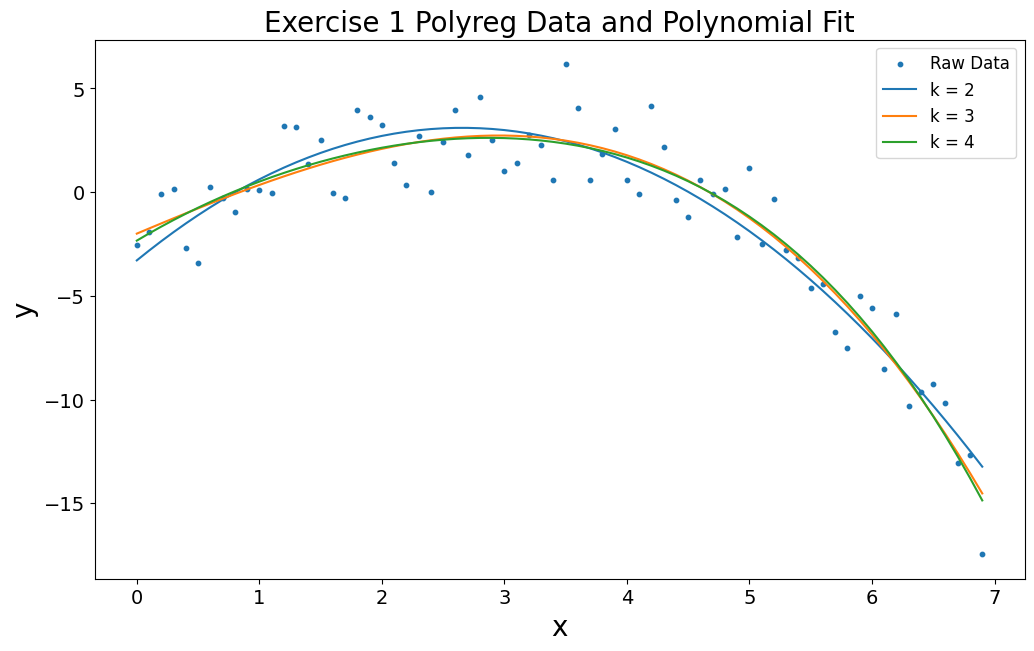

In [38]:
#Your code here
test_k = [2,3,4]

x_data = xy_data[:,0]      # First column of array (indexed by 0) contains the x
y_data = xy_data[:,1]  # Second column of array (indexed by 1) contains the y


# Set parameters to make sure figures are large enough. You can try changing these values
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14

plt.scatter(x_data, y_data, s=10,label="Raw Data")   # s can be used to adjust the size of the dots
plt.xlabel('x')
plt.ylabel('y')
plt.title('Exercise 1 Polyreg Data and Polynomial Fit')


# Generate Polynomial
for k in test_k:
    beta_k, fit_k, residuals_k = polyreg(xy_data, k)
    # Plot the polynomial
    plt.plot(x_data, fit_k, label='k = ' + str(k))
    print("For k = " + str(k) + ":")
    print("SSE = " + str(np.sum(residuals_k**2)))
    print("R^2 = " + str(1 - np.sum(residuals_k**2)/np.sum((y_data - np.mean(y_data))**2)))
plt.legend(fontsize = 'large')
plt.show()

 #### State which model you choose and briefly justify your choice.

Despite the additional computation complexity of k=4(very small difference), k=4 produces a better R^2



### 1d)  For the model you have chosen in the previous part (either $k=2/3/4)$:

- Plot the residuals in a scatter plot.
- Plot a histogram of the residuals along with a Gaussian pdf with zero mean and the same standard deviation as the residuals.

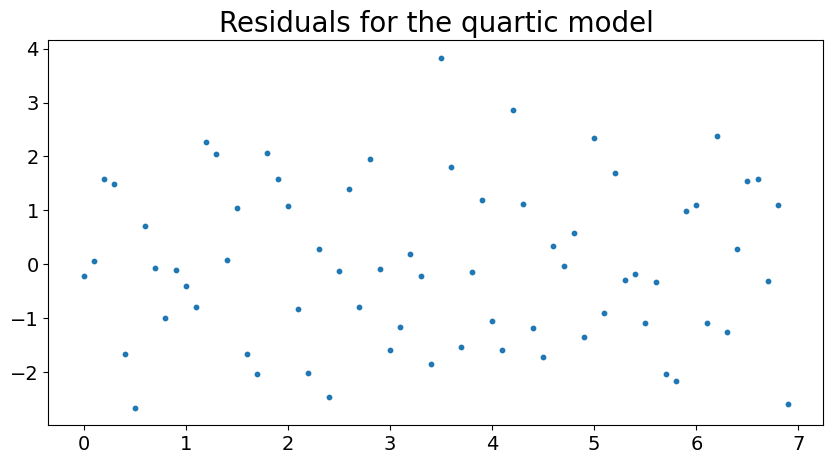

Mean of residuals for quartic model =  -0.0 Variance of residuals =  2.16


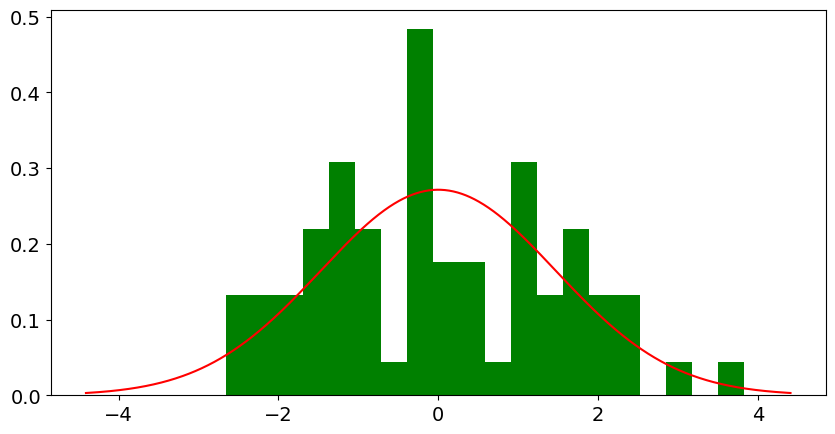

In [46]:
#Your code here

# Plot Gaussian pdf with same mean and variance as the residuals
from scipy.stats import norm
beta_4, fit_4, residuals_4 = polyreg(xy_data, 4)

plt.rcParams['figure.figsize'] = [10, 5]
plt.scatter(x_data, residuals_4, s=10)
plt.title('Residuals for the quartic model')
plt.show()

print('Mean of residuals for quartic model = ', np.round(np.mean(residuals_4), 3),
      'Variance of residuals = ', np.round(np.var(residuals_4),3))

# Plot normed histogram of the residuals
n, bins, patches = plt.hist(residuals_4, bins=20, density=True, facecolor='green');

# Plot Gaussian pdf with same mean and variance as the residuals
res_quart_stdev = np.std(residuals_4)  #standard deviation of residuals
xvals = np.linspace(-3*res_quart_stdev,3*res_quart_stdev,1000)
plt.plot(xvals, norm.pdf(xvals, loc=0, scale=res_quart_stdev), 'r')
plt.show()
